# **Práctica 2.2**: Ataques adversarios y robustez en Visión Artificial con modelos de Deep Learning

# **Introducción**
Esta práctica tiene como objetivo evaluar la robustez de las Redes Neuronales Convolucionales (CNN) frente a ataques adversarios de "caja blanca" (*white-box*). En este escenario, el atacante tiene acceso total a los pesos y la arquitectura del modelo, permitiéndole calcular el gradiente de la función de pérdida respecto a la imagen de entrada.

Se utiliza el conjunto de datos **CIFAR-10** para entrenar un modelo base y, posteriormente, se implementa el ataque **Projected Gradient Descent (PGD)**. Este ataque se analiza bajo la norma $L_\infty$ para garantizar que las perturbaciones introducidas sean imperceptibles para el ojo humano, evaluando el equilibrio entre la precisión del modelo y su capacidad de generalización ante datos malintencionados.

---
### **Imports** necesarios y **fijado** **de** **semilla** para garantizar la reproducibilidad del notebook

In [1]:
import torch
import numpy as np
import random
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

!pip -q install adversarial-robustness-toolbox
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import SaliencyMapMethod

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Detección dinámica del dispositivo
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Usando backend: {device}")


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/IA en Ciberseguridad/Practicas/Practica2/CNN-Adversarial-Attacks-Defense/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando backend: mps


### **Definición de funciones auxiliares**

In [2]:
def train_model(model: nn.Module, epochs: int, optim: torch.optim.Optimizer, criterion: nn.Module, train_dataloader: DataLoader, device: torch.device):
    """
    Función encargada del enetrenamiento de un modelo

    [PARAMETERS]
        - modelo: nn.Module
        - epochs: int
        - optim: torch.optim.Optimizer
        - criterion: nn.Module
        - train_dataloader: torch.utils.data.Dataloader
        - device: torch.device
    """
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for imgs, labels in train_dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            optim.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optim.step()

            train_loss += loss.item()
        
        print(f'Época {epoch+1}/{epochs} - Loss: {train_loss / len(train_dataloader):.4f}')
    
    return model

def eval_model(model: nn.Module, test_dataloader: DataLoader, device: torch.device):
    """
    Función encargada de la evaluación de un modelo

    [PARAMETERS]
        - model: nn.Module
        - test_dataloader: torch.utils.data.Dataloader
        - device : torch.device
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_dataloader, desc='Evaluando modelo'):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

def visualize_predictions(model: nn.Module, loader: DataLoader, classes: list[str], device: torch.device):
    """
    Función encargada de mostrar una visualización cómoda de la inferencia de un modelo

    [PARAMETERS]
        - model: nn.Module
        - loader: torch.utils.data.Dataloader
        - classes: list[str]
        - device: torch.device
    """
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:10].to(device), labels[:10].to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, 1)
    
    fig = plt.figure(figsize=(20, 7))
    fig.suptitle("Imágenes Originales", fontsize=20, fontweight='bold', y=1.05)
    
    for i in range(10): 
        plt.subplot(2, 5, i+1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        plt.imshow(np.clip(img, 0, 1))
        
        color = "green" if preds[i] == labels[i] else "red"
        plt.title(f"Pred: {classes[preds[i]]}\nReal: {classes[labels[i]]}", color=color, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_attack_impact(model: nn.Module, loader: DataLoader, classes: list[str], device: torch.device, attack_fn: callable, attack_params: dict, n: int=5):
    """
    Función encargada de la visualización del resultado de aplicar cierto ataque (attack_fn).

    [PARMETERS]
        - model: nn.Module
        - loader: torch.utils.data.Dataloader
        - classes: list[str]
        - device: torch.device
        - attack_fn: callable
        - atack_params: dict
        - n: int
    """
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:n].to(device), labels[:n].to(device)
    
    images_adv = attack_fn(model, images, labels, **attack_params)
    
    with torch.no_grad():
        preds_clean = torch.argmax(model(images), dim=1)
        preds_adv = torch.argmax(model(images_adv), dim=1)
        
    orig_np = images.cpu().numpy().transpose(0, 2, 3, 1)
    adv_np = images_adv.cpu().numpy().transpose(0, 2, 3, 1)
    
    perturbation = np.abs(adv_np - orig_np)
    perturbation = perturbation / (perturbation.max() + 1e-8) 

    name = attack_fn.__name__.upper().split('_')[0]
    clean_params = {k: v for k, v in attack_params.items() if isinstance(v, (int, float, str))}
    params_str = ", ".join([f"{k}: {v}" for k, v in clean_params.items()])
    
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 9))
    fig.suptitle(f"Impacto del Ataque: {name}\n({params_str})", fontsize=16, fontweight='bold', y=1.02)
    
    for i in range(n):
        axes[0, i].imshow(np.clip(orig_np[i], 0, 1))
        color = "green" if preds_clean[i] == labels[i] else "red"
        axes[0, i].set_title(f"Pred: {classes[preds_clean[i]]}", color=color, fontsize=9)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(perturbation[i])
        axes[1, i].set_title("Perturbación (δ)", fontsize=9)
        axes[1, i].axis('off')
        
        axes[2, i].imshow(np.clip(adv_np[i], 0, 1))
        color = "green" if preds_adv[i] == labels[i] else "red"
        axes[2, i].set_title(f"Pred Adv: {classes[preds_adv[i]]}", color=color, fontsize=9)
        axes[2, i].axis('off')
        
    plt.tight_layout()
    plt.show()

---
## **Parte 1 - Modelo base sobre CIFAR-10**

### **1.1 Descripción del dataset CIFAR-10**

El conjunto de datos `CIFAR-10` es un estándar en la comunidad de aprendizaje profundo para tareas de clasificación de imágenes. Consta de un total de 60,000 imágenes a color (3 canales RGB) de baja resolución (32x32 píxeles), distribuidas uniformemente en 10 clases: `avión`, `coche`, `pájaro`, `gato`, `ciervo`, `perro`, `rana`, `caballo`, `barco` y `camión`.

Para esta práctica, utilizaremos la partición estándar de 50,000 imágenes para entrenamiento y 10,000 imágenes para test, lo que nos permitirá evaluar la capacidad de generalización del modelo antes de someterlo a perturbaciones adversarias.

### **1.2 Preprocesamiento**

A diferencia de los flujos de trabajo convencionales, hemos diseñado un preprocesamiento específico para facilitar la generación de ataques adversarios:
- **Conversión a Tensor**: Las imágenes se transforman a tensores de PyTorch, escalando sus valores al rango $[0, 1]$.
- **Normalización Interna**: No aplicaremos la normalización estadística (sustracción de la media y división por la desviación típica) en el `DataLoader`. En su lugar, esta operación se integrará directamente en la arquitectura de la red neuronal.
  - *Justificación*: Esto permite que el ataque adversario busque perturbaciones en el espacio físico real de la imagen, garantizando que el presupuesto $\epsilon$ sea directamente interpretable y evitando artefactos de "clipping" incorrectos.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/IA en Ciberseguridad/Practicas/Practica2/CNN-Adversarial-Attacks-Defense/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### **1.3 Definición de la arquitectura CNN**

Se ha implementado una red neuronal convolucional (`SimpleCNN`) optimizada para `CIFAR-10`. La arquitectura incluye:

- **Extracción de características**: Dos bloques convolucionales con activación ReLU y capas de Max-Pooling para reducir la dimensionalidad espacial.

- **Clasificación**: Capas totalmente conectadas con Dropout para mitigar el sobreajuste.

- **Capa de Normalización Integrada**: Utilizando register_buffer, el modelo almacena los parámetros estadísticos de `CIFAR-10`. Esto asegura que el modelo sea capaz de procesar imágenes en el rango $[0, 1]$ normalizándolas "al vuelo" antes de las capas convolucionales.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.register_buffer('mean', torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1))
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.linear_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8 , 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = (x - self.mean) / self.std
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.linear_layer(x)
        return x

model = SimpleCNN().to(device)
print('[INFO] Red CNN con normalización interna definida!')

[INFO] Red CNN con normalización interna definida!


### **1.4 Entrenamiento del modelo**

El modelo se entrena utilizando el optimizador `AdamW`, elegido por su eficiente manejo de la regularización L2 (`weight decay`). Se emplea una tasa de aprendizaje de $1e-3$ y la función de pérdida de Entropía Cruzada (`CrossEntropyLoss`). El proceso se lleva a cabo durante 20 épocas, buscando un equilibrio entre la convergencia de la pérdida y la estabilidad del accuracy en el conjunto de validación.

In [5]:
criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

model = train_model(model, 20, optim, criterion, train_loader, device)

Época 1/20 - Loss: 1.4091
Época 2/20 - Loss: 1.0184
Época 3/20 - Loss: 0.8710
Época 4/20 - Loss: 0.7719
Época 5/20 - Loss: 0.6789
Época 6/20 - Loss: 0.6043
Época 7/20 - Loss: 0.5380
Época 8/20 - Loss: 0.4751
Época 9/20 - Loss: 0.4198
Época 10/20 - Loss: 0.3746
Época 11/20 - Loss: 0.3305
Época 12/20 - Loss: 0.2958
Época 13/20 - Loss: 0.2713
Época 14/20 - Loss: 0.2418
Época 15/20 - Loss: 0.2269
Época 16/20 - Loss: 0.2086
Época 17/20 - Loss: 0.1949
Época 18/20 - Loss: 0.1889
Época 19/20 - Loss: 0.1718
Época 20/20 - Loss: 0.1601


### **1.5 Evalución inicial**
Una vez finalizado el entrenamiento, procedemos a realizar una evaluación inicial en el conjunto de test "limpio" (sin ataques). El objetivo es establecer un *baseline* que nos sirva para cuantificar la pérdida de precisión ante ejemplos adversarios. Además, visualizaremos una muestra de predicciones donde el color del título indicará si la clasificación ha sido correcta (verde) o errónea (rojo).

In [6]:
clean_acc = eval_model(model, test_loader, device)
print(f"Accuracy en el conjunto de test original: {clean_acc * 100:.2f}%")

Evaluando modelo:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluando modelo: 100%|██████████| 79/79 [00:00<00:00, 104.10it/s]

Accuracy en el conjunto de test original: 74.88%


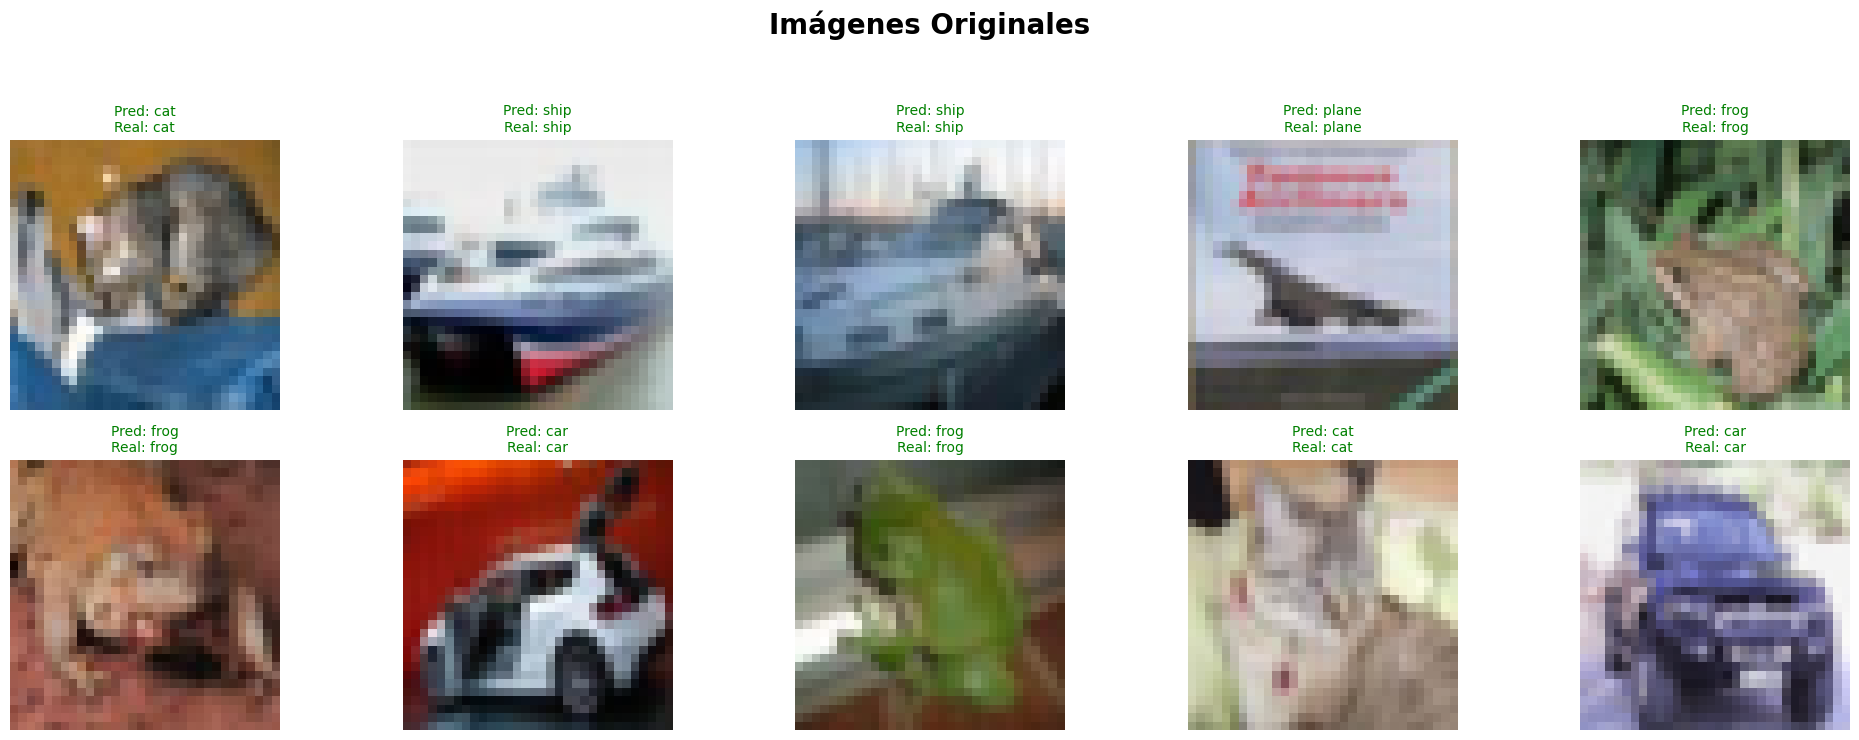

In [7]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
visualize_predictions(model, test_loader, classes, device)

---
## **Parte 2 - Ataques adversarios**

Es este apartado del cuaderno se desarrollará la lógica necesaria para generar ejemplos adversarios y evaluar la robustez de la red entrenada previamente.

Para ello, se implementarán funciones de soporte encargadas de calcular las métricas de éxito del ataque y de cuantificar la magnitud de las perturbaciones introducidas. El objetivo principal será definir un marco para la evaluación de la robustez del modelo frente a diferentes niveles de ataque *white-box*

In [9]:
def make_target_labels(y, num_classes=10, strategy="next"):
    """
    Función encargada de obtener la representación de etiquetas correcta dada una estrategia de ataque dirigido (One-Hot)
    """
    y_np = np.array(y, dtype=np.int32).reshape(-1)
    if strategy == "next": tgt = (y_np + 1) % num_classes
    elif strategy == "farthest": tgt = (y_np + (num_classes // 2)) % num_classes
    else:
        try:
            c = int(strategy)
            tgt = np.full_like(y_np, c)
        except:
            raise ValueError("Estrategia de objetivos no soportada.")

    y_tgt = np.zeros((y_np.shape[0], num_classes), dtype=np.float32)
    y_tgt[np.arange(y_np.shape[0]), tgt] = 1.0
    return y_tgt, tgt

def compute_norms(delta, l0_thresh=1e-6):
    """
    Calcula las normas L0, L2 y Linf para un batch de perturbaciones en PyTorch.
    delta: torch.Tensor de forma (N, C, H, W)
    """
    delta_abs = torch.abs(delta)
    
    l_inf = torch.amax(delta_abs, dim=[1, 2, 3])
    l2 = torch.norm(delta.view(delta.shape[0], -1), p=2, dim=1)
    l0 = torch.sum((delta_abs > l0_thresh).float(), dim=[1, 2, 3])
    
    return l0, l2, l_inf


def evaluate_attack(model: SimpleCNN, data_loader: DataLoader, attack_fn: callable, attack_params: dict, device: torch.device, max_batches: int = None, targeted_attack: bool = False):
    """
    Función encargada de los resultados de un ataque de tipo white-box dado un modelo de clasificación.
    
    [PARÁMETROS]
        * model: SimpleCNN - Modelo sobre el cual vamos a realizar el ataque.
        * data_loader: DataLoader - Objeto encargado de cargar el conjunto de datos sobre el que se va a realizar el ataque.
        * attack_fn: callable - Ataque seleccionado para su evaluación.
        * attack_params: dict - Parámetros del ataque.
        * device: torch.device - Device donde se esta realizando la ejecución del cuaderno.
        * max_batches: int - Parametro opcional que sirve para limitar el numero de batches para la evalución del ataque. Este se añade con la finalidad de hacer más ligera la evaluación
        * targeted_attack: bool - Parámetro booleno que sirve para diferenciar la evaluación de un ataque guiado o no.
    
    [RETURN]
        * res: dict - Diccionario que recogerá las métricas básicas de evaluación de ataques white-box: 
            - clean_accuracy, 
            - robust_accuracy, 
            - ASR, 
            - TSR (solo si el ataque es dirigido)
            - L_0
            - L_2
            - L_inf
    """
    n_total = 0
    n_clean_correct = 0
    n_adv_correct = 0
    n_success_attack = 0
    
    if targeted_attack:
        n_target_success = 0

    l0_list, l2_list, linf_list = [], [], []

    model.eval()

    for b_idx, (x, y) in enumerate(tqdm(data_loader, desc="Evaluando ataque sobre conjunto de datos")):
        
        if (max_batches is not None) and (b_idx >= max_batches): break

        model.to(device)
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            pred_clean = torch.argmax(out, dim=1)


        x_adv = attack_fn(model, x, y, **attack_params)
        with torch.no_grad():
            out = model(x_adv)
            pred_adv = torch.argmax(out, dim=1)
        
        # Añadir logica de target label en caso de ataque guiado
        if targeted_attack:
            _, y_tgt = make_target_labels(y.cpu().numpy(), strategy=attack_params['target_strategy'])
            y_tgt = torch.from_numpy(y_tgt).to(device)

        n_batch = x.shape[0]
        n_total += n_batch

        clear_correct_mask = (y == pred_clean)
        adv_correct_mask = (y == pred_adv)
        adv_wrong_mask = (y != pred_adv)

        n_clean_correct += clear_correct_mask.sum().item()
        n_adv_correct += adv_correct_mask.sum().item()
        n_success_attack += (clear_correct_mask & adv_wrong_mask).sum().item()
        if targeted_attack:
            n_target_success += (pred_adv == y_tgt).sum().item()

        delta = x_adv - x
        l0, l2, linf = compute_norms(delta)
        l0_list.extend(l0.detach().cpu().numpy())
        l2_list.extend(l2.detach().cpu().numpy())
        linf_list.extend(linf.detach().cpu().numpy())
    
    clean_acc = n_clean_correct / n_total
    adv_acc = n_adv_correct / n_total
    ASR = n_success_attack / (n_clean_correct + 1e-9)

    res = {
        "clean_accuracy": clean_acc,
        "robust_accuracy": adv_acc,
        "ASR": ASR,
        "mean_L0": float(np.mean(l0_list)),
        "mean_L2": float(np.mean(l2_list)),
        "mean_Linf": float(np.mean(linf_list))
    }

    if targeted_attack:
        res['TSR'] = n_target_success / n_total

    return res


### **2.1 Projected Gradient Descent - PGD**

Como primer ataque adeversario, se ha decidido implementar **Projected Gradient Descent (PGD)** como eje central de la evaluación de robustez. Esta elección fundamentalmene es porque PGD es considerado como el **Estado del Arte** (SoTA) entre los ataques de primer orden basados en signo de gradiente.

La principal ventaja, y segunda razón de la selección de este ataque como primera implementación, es su modularidad, ya que PGD puede llegar a funcionar como una generalización de los otros ataques fundamentales basados en signo de gradiente. Esto se consigue al ajustar los parámetros de iteraciones (`steps`) y reinicios aleatorios (`restarts`), podemos emular y comparar tres ataques diferentes con una única base de código:

1. **FGSM (Fast Gradient Sign Method)**: Configurando `steps=1`, `restarts=None` y `alpha = epsilon`. Es el ataque más rápido y simple de un solo paso.
2. **BIM (Basic Iterative Method)**: Configurando `steps > 1` y `restarts=None`. Es la versión iterativa del anterior ataque (FSGM) sin aleatoriedad inicial.
3. **PGD (Projected Gradient Descend)**: Configurando `steps > 1` y `restarts > 1`. Añade reinicios aleatorios para evitar que el ataque se quede atrapado en un máximo local, siendo este el ataque más potente de los tres.

Esta estrategia permite realizar una comparativa exhaustiva de la robustez del modelo frente a diferentes niveles de agresividad de ataque.

In [10]:
def _pgd_core(model: SimpleCNN, x: torch.tensor, y: torch.tensor, steps: int, alpha, epsilon: float, clip_min:float = 0.0, clip_max: float = 1.0):
    """
    Nucleo de la implementación del ataque PGD
    """
    x_adv = x.clone().detach()

    noise = torch.empty_like(x).uniform_(-epsilon, epsilon).to(x.device)
    x_adv = x_adv + noise
    x_adv = torch.clamp(x_adv, clip_min, clip_max)

    x_adv.requires_grad_(True)

    criterion = nn.CrossEntropyLoss()

    for _ in range(steps):

        out = model(x_adv)
        loss = criterion(out, y)
        loss.backward()

        with torch.no_grad():
            grad_sing = torch.sign(x_adv.grad)
            x_adv.data = x_adv.data + alpha * grad_sing
            x_adv.data = x.data + torch.clamp(x_adv.data - x.data, min=-epsilon, max=epsilon)
            x_adv.data = torch.clamp(x_adv.data, clip_min, clip_max)
        
        x_adv.grad.zero_()
          
    return x_adv.detach()


def pgd_attack(model: SimpleCNN, x: torch.tensor, y: torch.tensor, restarts: int, steps: int, alpha: float = None, epsilon: float = 0.1, min_clip: float = 0.0, max_clip: float = 1.0):
    """
    Implementación del ataque PGD con posibilidad de varios reinicios 
    """
    model.eval()
    if alpha is None:
        alpha = epsilon / steps
    
    criterion = nn.CrossEntropyLoss(reduction='none')

    if restarts <= 1:
        return _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
    
    best_x_adv = x.clone().detach()
    best_loss = torch.full((x.shape[0],), -1e9, device=x.device)
    for _ in range(restarts):
        x_adv_candidate = _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
        with torch.no_grad():
            out = model(x_adv_candidate)
            current_loss = criterion(out, y)
        
            better = current_loss > best_loss
            best_loss[better] = current_loss[better]

            best_x_adv[better] = x_adv_candidate[better]

    return best_x_adv

### **2.2 Jacobian-based Saliency Map Attack (JSMA)**

Tras la elección un ataque white-box de primer order como primera opción, como segundo ataque se decide implementar el **Jacobian-based Saliency Map Attack (JSMA)** para analizar la vulnerabilidad del modelo desde una perspectiva de clases de equivalencia y prominencia de características. A diferencia de los ataques anteriores basados en la norma $L_\infty$, JSMA se centra en la optimización de la norma $L_0$, buscando minimizar el número de píxeles modificados mientras se maximiza el impacto en la clasificación.

La elección de JSMA responde a dos objetivos estratégicos:

- **Ataque Quirúrgico**: Evaluar si el modelo puede ser engañado alterando apenas una fracción mínima de la imagen (píxeles críticos), lo que contrasta con el ruido distribuido del PGD
- **Naturaleza Dirigida (Targeted)**: A diferencia de las pruebas anteriores, JSMA utiliza la matriz Jacobiana para forzar al modelo a predecir una clase objetivo específica (Targeted Success Rate), permitiendo medir no solo la fragilidad del modelo, sino también su manipulabilidad hacia resultados predeterminados por el atacante.

In [ ]:
def jsma_attack(model: staticmethod, x: torch.tensor, y: torch.tensor, criterion: nn.Module, optimizer: torch.optim.Optimizer, device: str, gamma: float, theta: float, target_strategy: (str|int) ="next"):
    """
    Implementación del ataque dirigido JSMA (Jacobian Salienci Map Attack)
    """
    attack_device = "cpu" if device.type == "mps" else device.type      # Para MacOS, 'adversarial-robustness-toolbox' aun no está optimizado el uso de su chip "MPS"
    try:
        model.to(attack_device)
        model.eval()

        classifier = PyTorchClassifier(
            model=model,
            clip_values=(0.0, 1.0),
            loss=criterion,
            optimizer=optimizer,
            input_shape=(3, 32, 32),
            nb_classes=10,
            device_type=attack_device
        )

        x_np = x.cpu().detach().numpy()
        y_np = y.cpu().detach().numpy()
        y_target_onehot, _ = make_target_labels(y_np, num_classes=10, strategy=target_strategy)

        attack = SaliencyMapMethod(
            classifier=classifier,
            theta=theta,
            gamma=gamma,
            batch_size=x_np.shape[0],
            verbose=False
        )

        x_adv_np = attack.generate(x=x_np, y=y_target_onehot)
        return torch.from_numpy(x_adv_np).to(device)

    finally:
        model.to(device)

---
## **Parte 3 - Evaluación de robustez**

En esta apartado se recogerá un análisis cuantitativo de la vulnerabilidad de nuestro modelo comparando el ataque PGD (basado en el signo del gradiente y con restricciones en la norma $L_\infty$) frente al ataque JSMA (basado en la prominiencia de la matriz Jacobiana y restricciones en la norma $L_0$).

### **3.1 Análisis de PGD**

Como PGD es un ataque iterativo que busca el peor escenario dentro de una "bola" de radio $\epsilon$, realizaremos las siguientes pruebas:

- **Efectividad del ataque:** Se comparará el Accuracy original (Accuracy Limpio) frente al Accuracy bajo ataque (Accuracy Robusto) y además, comprobaremos la tasa de exito del ataque (ASR) con diferentes valores de $\epsilon$ (ej, 0.01, 0.05, 0.1)
- **Convergencia:** Analizar si aumentar el número de pasos (`steps`) realmente hace mas efectivo este ataque o si el modelo se estabiliza a partir de un cierto valor de pasos.
- **Métricas:** Finalmente se mostrará un reporte de la media de las normas ($L_1$, $L_2$, $L_\infty$) para verificar, por un lado que se respeta el valor de "presupuesto" ($\epsilon$) establecido ($L_\infty$), y por otro analizar el valor del resto de normas

<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
/var/folders/lj/j9wc0z614bl2r5gdk_5k_n240000gn/T/ipykernel_51188/114687486.py:65: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Epsilon ($\epsilon$)')
/var/folders/lj/j9wc0z614bl2r5gdk_5k_n240000gn/T/ipykernel_51188/114687486.py:72: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Análisis de Convergencia ($\epsilon$={fixed_eps})')


Iniciando evaluación de robustez PGD...
Evaluando Epsilon: 0.005...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [00:00<00:04, 15.25it/s]


Evaluando Epsilon: 0.01...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [00:00<00:04, 15.52it/s]


...

Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [00:00<00:02, 27.33it/s]


Evaluando Steps: 15...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [00:00<00:05, 11.70it/s]


Evaluando Steps: 20...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [00:01<00:07,  9.07it/s]


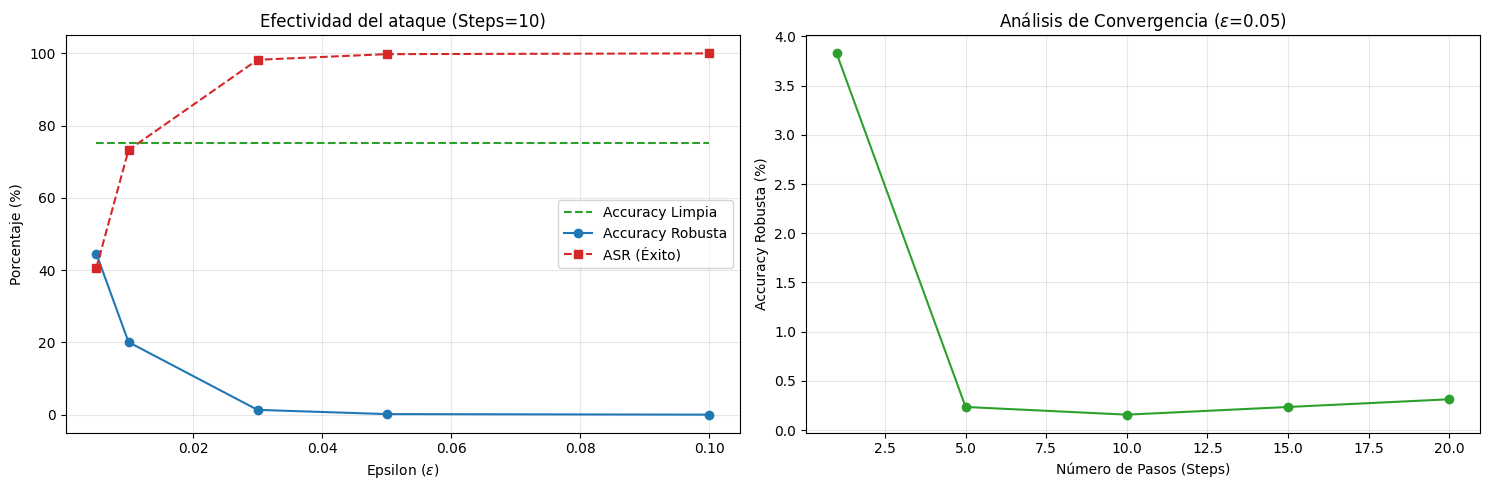


	REPORTE FINAL DE NORMAS (Promedios)


,config,robust_accuracy,ASR,mean_L0,mean_L2,mean_Linf
0,eps=0.005; steps=10,0.446094,0.405827,3056.538330,0.212005,0.005
1,eps=0.01; steps=10,0.200781,0.732570,3057.656250,0.412865,0.010
2,eps=0.03; steps=10,0.013281,0.982310,3058.789062,1.178816,0.030
3,eps=0.05; steps=10,0.001563,0.997919,3059.315674,1.921258,0.050
4,eps=0.1; steps=10,0.000000,1.000000,3060.490723,3.740904,0.100
5,eps=0.05; steps=1,0.038281,0.949011,3052.375732,2.251767,0.050
6,eps=0.05; steps=5,0.002344,0.996878,3058.878906,1.918725,0.050
7,eps=0.05; steps=15,0.002344,0.996878,3059.658691,1.926307,0.050
8,eps=0.05; steps=20,0.003125,0.995838,3059.728027,1.928609,0.050


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Configuración del Experimento ---
eps_values = [0.005, 0.01, 0.03, 0.05, 0.1]
step_values = [1, 5, 10, 15, 20]
fixed_steps = 10    # Pasos fijos para el análisis de Epsilon
fixed_eps = 0.05    # Epsilon fijo para el análisis de Convergencia
max_batches_eval = 10 # Limitar para rapidez; poner `None` para test completo

results_pgd = []

print("Iniciando evaluación de robustez PGD...")

# --- 2. Ejecución: Variando Epsilon ---
for eps in eps_values:
    params = {
        'epsilon': eps,
        'alpha': eps / fixed_steps,
        'steps': fixed_steps,
        'restarts': 1
    }
    print(f"Evaluando Epsilon: {eps}...")
    res = evaluate_attack(model, test_loader, pgd_attack, params, device, max_batches=max_batches_eval)
    res['config'] = f"eps={eps}; steps={fixed_steps}"
    res['epsilon'] = eps
    res['steps'] = fixed_steps
    res['tipo_test'] = 'epsilon_variante'
    results_pgd.append(res)

# --- 3. Ejecución: Variando Steps  ---
for stp in step_values:
    if stp == fixed_steps: continue 
    params = {
        'epsilon': fixed_eps,
        'alpha': fixed_eps / stp,
        'steps': stp,
        'restarts': 1
    }
    print(f"Evaluando Steps: {stp}...")
    res = evaluate_attack(model, test_loader, pgd_attack, params, device, max_batches=max_batches_eval)
    res['config'] = f"eps={fixed_eps}; steps={stp}"
    res['epsilon'] = fixed_eps
    res['steps'] = stp
    res['tipo_test'] = 'steps_variante'
    results_pgd.append(res)

# --- 4. Resultados ---
df_res = pd.DataFrame(results_pgd)

# Separar datos para gráficas
df_eps = df_res[df_res['tipo_test'] == 'epsilon_variante'].sort_values('epsilon')
df_stp = df_res[(df_res['tipo_test'] == 'steps_variante') | 
                ((df_res['epsilon'] == fixed_eps) & (df_res['steps'] == fixed_steps))].sort_values('steps')

# --- 5. Visualización de Resultados ---
plt.figure(figsize=(15, 5))

# Gráfica A: Accuracy vs Epsilon
plt.subplot(1, 2, 1)
plt.plot(df_eps['epsilon'], df_eps['clean_accuracy'] * 100, '--', color='tab:green', label='Accuracy Limpia')
plt.plot(df_eps['epsilon'], df_eps['robust_accuracy'] * 100, 'o-', color='tab:blue', label='Accuracy Robusta')
plt.plot(df_eps['epsilon'], df_eps['ASR'] * 100, 's--', color='tab:red', label='ASR (Éxito)')
plt.title(f'Efectividad del ataque (Steps={fixed_steps})')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Porcentaje (%)')
plt.grid(True, alpha=0.3); plt.legend()

# Gráfica B: Accuracy vs Steps (Convergencia)
plt.subplot(1, 2, 2)
plt.plot(df_stp['steps'], df_stp['robust_accuracy'] * 100, 'o-', color='tab:green')
plt.title(f'Análisis de Convergencia ($\epsilon$={fixed_eps})')
plt.xlabel('Número de Pasos (Steps)')
plt.ylabel('Accuracy Robusta (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 6. Reporte de Métricas y Normas ---
print("\n" + "="*60)
print("\tREPORTE FINAL DE NORMAS (Promedios)")
print("="*60)
display(df_res[['config', 'robust_accuracy', 'ASR', 'mean_L0', 'mean_L2', 'mean_Linf']])

Como se aprecia en las gráficas, tanto el valor de $\epsilon$ como el número de pasos están fuertemente relacionados con la efectividad del ataque (ASR). El aumento de ambos parámetros se traduce en una disminución de la Exactitud Robusta (robust accuracy), lo cual es coherente: estamos permitiendo una perturbación de mayor magnitud y otorgando más iteraciones para optimizar la pérdida.
1. **Análisis del valor $\epsilon$:** A medida que $\epsilon$ aumenta, la precisión del modelo cae drásticamente. Sin embargo, en ciberseguridad el objetivo es el compromiso entre éxito e imperceptibilidad. Observando los resultados, $\epsilon = 0.03$ ya alcanza un ASR del $98.5\%$. Pasar a $0.05$ solo sube un $1.3\%$ la efectividad a cambio de aumentar el riesgo de detección visual. Por tanto, $\epsilon = 0.03$ se identifica como el valor óptimo para un ataque quirúrgico.
2. **Análisis del número de pasos:** El número de pasos permite al ataque aproximarse al máximo local de la función de pérdida mediante el gradiente. La gráfica ASR vs. Nº pasos muestra una saturación temprana: con solo 10 pasos ya se logra la máxima efectividad práctica. Aumentar este valor solo incrementaría el coste computacional sin aportar una ventaja táctica significativa, por lo que 10 pasos es la configuración más eficiente.

### **3.2 Análisis de JSMA**

En este aparado se evaluará la eficiencia de JSMA para conseguir engañar al modelo con la mínima modificación posible. Para ello, se realizarán las siguientes pruebas:

- **Tasa de acierto dirijida (TSR):** A diferencia de PGD, JSMA busca engañar al modelo con cada imagen con una clase específica. Para ello se reportará esta métrica, la cual recoge cuántas imágenes logran convertirse con éxito en la clase "objetivo" predefinida.
- **Análisis de Gamma ($\gamma$):** Se evaluará como varía el exito de nuestro ataque al permitir modificar desde un 1% hasta un 10% los píxeles de nuestra imagen.
- **Métricas:** De nuevo se mostrará un reporte de las normas conocidas ($L_1$, $L_2$, $L_\infty$), poniendo el foco principal sobre la norma $L_0$, la cual indica el número promedio de píxeles que han sido necesarios para que el modelo cambie su predicción.

<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:37: SyntaxWarning: invalid escape sequence '\g'
/var/folders/lj/j9wc0z614bl2r5gdk_5k_n240000gn/T/ipykernel_51188/806175844.py:37: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Efectividad de JSMA vs. Presupuesto de Píxeles ($\gamma$)')


Iniciando análisis de JSMA (esto puede tardar unos minutos)...
Evaluando JSMA con Gamma = 0.01...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [01:25<09:53,  8.60s/it]


Evaluando JSMA con Gamma = 0.04...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [03:38<25:08, 21.86s/it]


Evaluando JSMA con Gamma = 0.08...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [04:20<29:59, 26.08s/it]


Evaluando JSMA con Gamma = 0.12...


Evaluando ataque sobre conjunto de datos:  13%|█▎        | 10/79 [04:36<31:50, 27.69s/it]


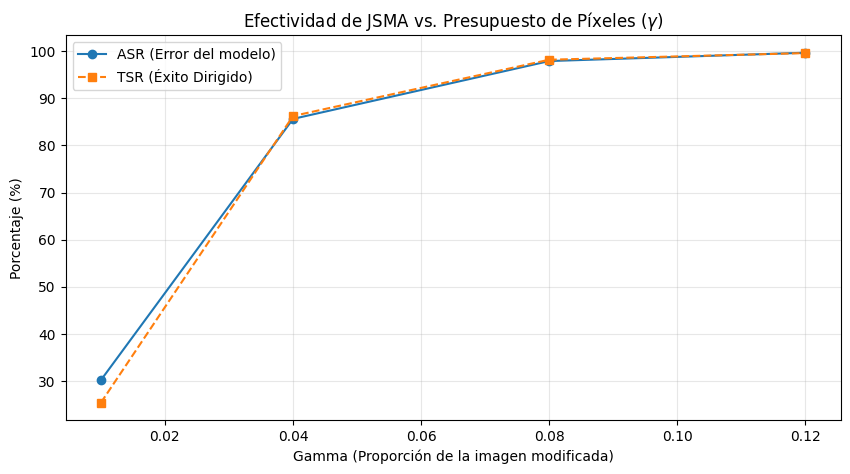


 REPORTE DE MÉTRICAS JSMA (Análisis L0)


,gamma,ASR,TSR,mean_L0,mean_L2,mean_Linf
0,0.01,0.301769,0.253906,27.639063,1.089730,0.527001
1,0.04,0.856400,0.862500,63.435158,1.662768,0.614910
2,0.08,0.979188,0.982031,70.335159,1.739836,0.620953
3,0.12,0.996878,0.996094,71.531250,1.750302,0.621302


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Configuración del Experimento JSMA ---
gamma_values = [0.01, 0.04, 0.08, 0.12] 
jsma_results = []

base_params_jsma = {
    'device': device,
    'criterion': criterion,
    'optimizer': optim,
    'theta': 0.1,           # Intensidad de la modificación por píxel
    'target_strategy': 'next' # Clase objetivo: (clase_real + 1) % 10
}

print("Iniciando análisis de JSMA (esto puede tardar unos minutos)...")

for g in gamma_values:
    print(f"Evaluando JSMA con Gamma = {g}...")
    current_params = {**base_params_jsma, 'gamma': g}

    res = evaluate_attack(model, test_loader, jsma_attack, current_params, device, max_batches=10, targeted_attack=True)
    
    res['gamma'] = g
    jsma_results.append(res)

# --- 2. Procesamiento de Resultados ---
df_jsma = pd.DataFrame(jsma_results)

# --- 3. Visualización de la Efectividad ---
plt.figure(figsize=(10, 5))

# ASR vs TSR
plt.plot(df_jsma['gamma'], df_jsma['ASR'] * 100, 'o-', label='ASR (Error del modelo)')
plt.plot(df_jsma['gamma'], df_jsma['TSR'] * 100, 's--', label='TSR (Éxito Dirigido)')

plt.title('Efectividad de JSMA vs. Presupuesto de Píxeles ($\gamma$)')
plt.xlabel('Gamma (Proporción de la imagen modificada)')
plt.ylabel('Porcentaje (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 4. Reporte de Normas y Métricas ---
print("\n" + "="*50)
print(" REPORTE DE MÉTRICAS JSMA (Análisis L0)")
print("="*50)
display(df_jsma[['gamma', 'ASR', 'TSR', 'mean_L0', 'mean_L2', 'mean_Linf']])

El ataque JSMA se ha evaluado bajo una estrategia dirigida (`target_strategy=next`), donde el objetivo no es solo forzar el error, si no que el modelo clasifique una imagen en una categoría específica elegida por el atacante.

1. **Relación entre $\gamma$ y efectividad**: 
- Como se observa en la gráfica, existe una relación directa entre el presupuesto de modificación permitido ($\gamma$) y el éxito del ataque. Los resultados muestran un punto de saturación muy temprano:
    - Con $\gamma$ = 0.08, ya alcanzamos un ASR y TSR del 98%.
    - Con $\gamma$ = 0.12, ambos escalan a valores del 99%.

- Esto se traduce en una vulnerabilidad crítica, ya que el atacante solo necesitará modificar una fracción mínima para tomar el control de la predicción de nuestro modelo. La elección del valor óptimo dependerá del objetivo del atacante: un $\gamma$ = 0.08 ofrece un equilibrio superior al ser menos intrusivo visualmente, obteniendo una gran efectividad casi total.
2. **Convergencia de ASR y TSR**:
- Es muy destacable que los valores de ASR y TSR sean prácticamente idénticos en todas las pruebas.
  - En ataques no dirigidos, el exito se mide simplemente en la envasión del ataque frente al modelo.
  - Pero en este caso, el exito no solo se debe de medir con la evasión, al usar la extrategia 'next', el hecho de que TSR $\approx$ ASR demuestra la gran precisión de JSMA. No solo conseguimos que el modelo falle, si no que conseguimos que se equivoque extactamente como nosotros queremos.

### **3.3 Comparativa: Ruido difuso (PGD) vs. Cambios mínimos (JSMA)**

A continuación, se recoge una tabla comparativa de la eficacia de los dos anteriores ataques evaluados de manera individual:

| Métrica / Característica | PGD (Projected Gradient Descent) | JSMA (Saliency Map Method) |
| :--- | :--- | :--- |
| **Norma de perturbación** | $L_\infty$ (Global / Ruido) | $L_0$ (Focalizada / Píxeles clave) |
| **Comportamiento** | Distribuye el ruido por toda la imagen | Modifica solo los píxeles más relevantes |
| **Perceptibilidad** | Baja (parece ruido de fondo) | Baja (parece suciedad o artefactos) |
| **Eficiencia** | Alta, requiere iteraciones | Alta, es muy "quirúrgico" |

- **Naturaleza del ataque:** Mientras que PGD explota la fragilidad del modelo ante variaciones globales (añadiendo una capa de "niebla" matemática que el modelo no sabe interpretar), JSMA es mucho más elegante y destructivo a pequeña escala. JSMA identifica los "puntos de giro" (pixeles con mayor gradiente) y altera solo esos para forzar la clasificación errónea.
- **Resultados observados:** Hemos observado que con un $\epsilon$ pequeño, PGD puede fallar si el modelo tiene cierta robustez, pero JSMA es extremadamente eficaz con muy pocos píxeles alterados. Esto confirma que nuestro modelo es especialmente vulnerable a ataques "dirigidos" donde un atacante sabe exactamente qué píxeles son determinantes para la decisión.
- **Implicación de seguridad:** Este contraste demuestra que no podemos medir la robustez con una sola métrica. Un modelo puede ser "seguro" contra ruido aleatorio (PGD) pero totalmente expuesto a ataques estratégicos (JSMA).

### **3.4 Visualización de Resultados**

Por último, a continuación, se muestran ejemplos de los resultados de hacer los diferentes ataques implementados en este cuaderno:

Para la configuración de este ataque, se han seleccionado los parámetros identificados como óptimos en el análisis del apartado **3.1**, buscando maximizar la tasa de éxito (ASR) mientras se preserva la imperceptibilidad de la perturbación dentro de la bola $L_\infty$.

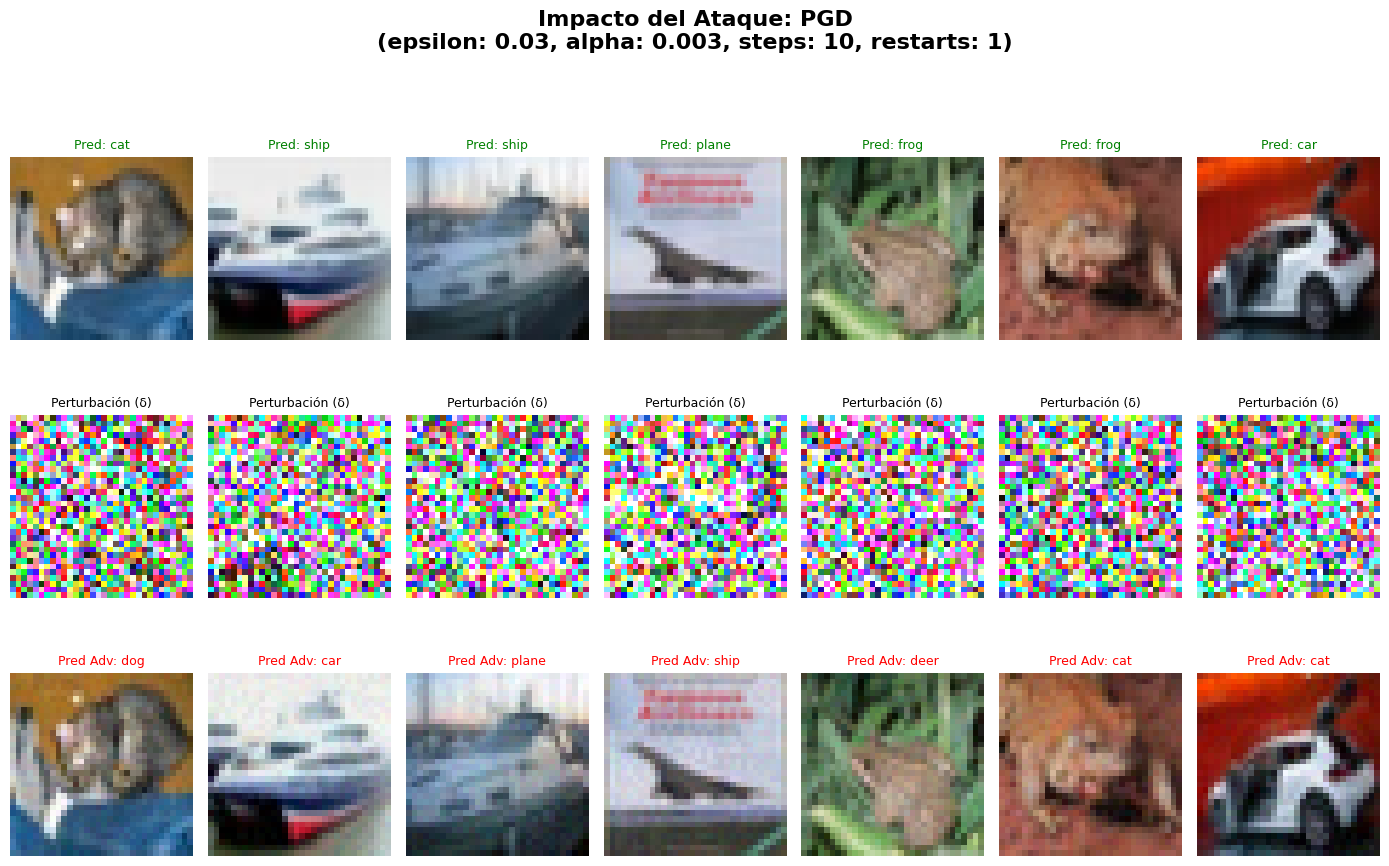

In [20]:
params = {
        'epsilon': 0.03,
        'alpha': 0.03 / fixed_steps,
        'steps': 10,
        'restarts': 1
    }
visualize_attack_impact(model, test_loader, classes, device, pgd_attack, params, n=7)

En base al estudio paramétrico del apartado **3.2**, se han seleccionado los valores óptimos de $\gamma$ (presupuesto de píxeles) y $\theta$ (intensidad) que maximizan tanto la tasa de éxito general (ASR) como la de objetivo (TSR).

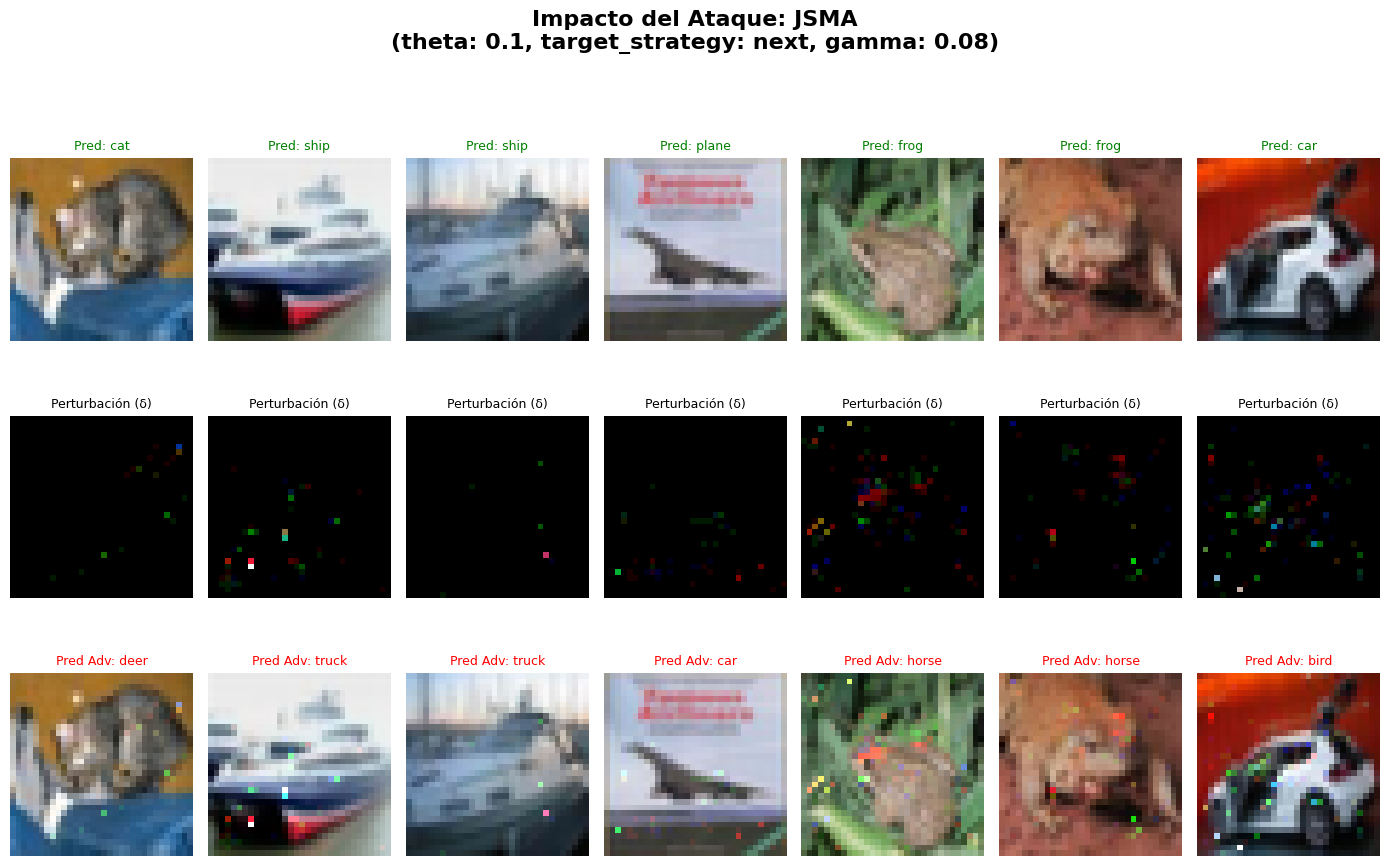

In [23]:
params = {
    'device': device,
    'criterion': criterion,
    'optimizer': optim,
    'theta': 0.1,           
    'target_strategy': 'next',
    'gamma': 0.08
}
visualize_attack_impact(model, test_loader, classes, device, jsma_attack, params, n=7)

***Nota:** Es muy interesante ver como JSMA coloca píxeles de manera estratégica que modifican los bordes o crear nuevas formas sutilmente. Por ejemplo para el ultimo ejemplo de la celda anterior, se puede observar como el ataque es capaz de replicar lo que parecen las alas y la cola de un pájaro para llevar a nuestro modelo a clasificar una imgen de un coche como un pájaro*

---
## **Parte 4 - Vulnerabilidades y defensas**

### **4.1 Análisis de vulnerabilidades**
A continuación se analizarán las diferentes debilidades observada en nuestro modelo base entrenado con el conjunto de datos CIFAR-10 al ser expuesto a diferentes ataques *white-box*:

- **Evasión**: El modelo ha demostrado ser altamente vulnerable antes ataques de evasión. Como se observan en los resultados del ataque **PGD**, basta con una pequeña perturbación de norma $L_\infty$ para que el clasificador cambie su predicción. Esto nos indica que el modelo no ha sido capaz de aprender características semánticas robustas de cada una de las clases, sino que lo aprendido durante el entrenamiento depende de correlaciones estadísticas frágiles en los píxeles.

- **Imperceptibilidad**: La clave de los ataques implementados (sobre todo PGD) es que operan bajo restricciones de norma que hacen que el ojo humano es casi incapaz de detectar. Mientras que nuestro modelo clasifica erroneamente la imagen adversaria, un humano sigue identificando la clase original sin ninguna complicación. Esto confirma que nuestra CNN está operando en un espacio latente donde las fronteras de decisisón están altamente ajustadas a los datos de entrenamiento y son muy sensibles a cambios imperceptibles.

- **Transferibilidad**: Aunque en este caso no hemos implementado un segundo modelo, dada la naturaleza de estos ataques (*white-box*), la cual busca explotar directamente la superficie de la pérdida de nuestra arquitectura, es altamente probable que estas mismas perturbaciones encontradas en nuestro modelo, para otros modelos entrenados sobre el mismo conjunto de datos, también consigan reducir notablemente el rendimiento de estos. Esto se debe, a que seguramente, durante el entrenamiento de este otro modelo, este haya aprendido patrones similares a los que ha aprendido nuestro modelo.

### **4.2 Propuestas de defensa**
Para conseguir mitigar las vulnverabilidades encontradas y detalladas en el anterior apartado se proponen las siguientes estrategias de defensa:

1. **Entrenamiento Adversario (*Adversarial Training*)**
   - **Fundamento:** Consiste en integrar ejemplos adeversarios (generados durante el entrenamiento con PGD o cualquiero otro ataque *white-box*) en el dataset, etiquetandolos con su clase correcta.
   - **Discusión:** Es la defensa robusta más conocida y en la que primero debemos de pensar si queremos añadir robustez a nuestros modelos de DeepLearning. Obliga al modelo a aprender características invariantes al ruido, haciendo menos rígidas las fronteras de decisión durante la clasificación.
   - **Limitación:** Pese a que se consigue aumentar la precisión de clasificación en imágenes ruidosas, la precisión en imágenes limpias se puede ver reducida. Además, el uso de esta técnica durante el entrenamiento implica un aumento exponencial en el coste computacional.

2. **Suavizado aleatorio (Randomized Smoothing)**
   - **Fundamento:** Esta técnica busca transformar un clasificador base en uno "suavizado". En lugar de realizar una inferencia directa, el modelo predice la clase basándose en un consenso (votación mayoritaria) de múltiples inferencias realizadas sobre la misma imagen de entrada tras añadirle ruido gaussiano aleatorio.
   - **Discusión:** Esta es, posiblemente, la defensa más potente de la literatura actual porque ofreze Robustez Certificada. Mientras que otras defensas intentan "ocultar" sus debilidades, *Randomized Smoothing* garantiza matemáticamente que, dentro de un radio $\epsilon$ determinado, la clase de la imagen no cambiará. Esto, aparte de ser una defensa empírica; es una prueba matemática de que el atacante no puede manipular la clasificación sin alteraar significativamente la imagen, de ahi que se diga que es una defensa que ofrece Robustez Certificada.
   - **Limitación:** Esta defensa aumenta en gran cantidad el tiempo de inferencia. Al necesitar realizar múltiples pases por el modelo (cientos o miles) para calcular el voto por mayoría, la latencia aumenta considerablemente. Además, a mayor robustez se deseé (radio mayor), menor será la precisión del modelo.

Tras analizar el impacto de los ataques implementados, se ha observado una diferencia fundamental en su comportamiento: mientras que PGD opera como un ataque de ruido global (norma $L_\infty$), el ataque JSMA es un ataque de precisión (norma $L_0$), capaz de manipular píxeles individuales para alterar la clasificación. Dado que las defensas orientadas a ruido (como las dos propuetas) no siempre consiguen neutralizar pertirbaciones tan específicas, se propone adicionalmente el uso de la siguiente:

3. **Feature Squeezing (Compresión de características)**
   - **Fundamento:** Consiste en reducir el espacio de búsqueda del atacante mediante la compresión de la información de entrada. Esto se logra reduciendo la profundidad de bits de la imagen (cuatización) o aplicando filtros de suavizado (como filtros de mediana o desenfoque) antes de que la entrada sea procesada por la red.
   - **Discusión:** Es una defensa orientada a los ataques de precisión como JSMA. Estos ataques dependen directamente de la capacidad de manipular valores de píxeles con gran precisión. Al cuantizar o filtrar la entrada, eliminamos ese margen de precisión. Si el atacante intenta añadir ruido de valor bajo, la compresión lo redondea o lo elimina.
   - **Limitaciones:** La principal limitación es que si el nivel de compresión es demasiado agresivo, se puede perder información relevante para la clasificación incluso para imágenes limpias.

### **4.3 Conclusiones**
En definitiva, la seguridad de un modelo como una CNN no dependerá de una única solución. La estrategia más efectiva será la **Defensa en Profundidad**, es decir, implementar varios mecanismos de defensa: el *Adversarial Training* protege contra la fuerza bruta, el *Randomized Smoothing* garantiza matemáticamente la estabilidad frente a perturbaciones, y el *Feature Squeezing* limpia el ruido de alta frecuencia que ataque dirigidos se encargan de explotar. La combinación de estas técnicas será lo que nos dé un buen mecanismo de defensa ante un adeversario que posea conocimiento total sobre el sistema (*white-box*).